<a href="https://colab.research.google.com/github/Luisafer1325/Telecomx_churn_analysis/blob/main/Telecom_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###***Telecom X - Análisis de Evasión de Clientes***

He sido contratada como asistente de análisis de datos en Telecom X y formaré parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.


Este proyecto tiene como objetivo analizar la evasión de clientes (Churn) en una empresa de telecomunicaciones.  
Se realizará un proceso de **extracción, limpieza, transformación y análisis exploratorio de datos (EDA)** para identificar patrones que expliquen por qué algunos clientes cancelan el servicio.

El análisis permitirá obtener **insights que ayuden a la empresa a mejorar la retención de clientes** y tomar decisiones estratégicas basadas en datos.

🔍 **EXTRACCIÓN DE DATOS**

En esta etapa se cargan los datos desde un archivo JSON y se transforman en un DataFrame de Pandas para facilitar su manipulación y análisis.


In [1]:
import requests
import pandas as pd

In [2]:
# Cargar archivo
telecom_data = pd.read_json('/content/TelecomX_Data.json')

In [3]:
telecom_data

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


🔑**TRANSFORMACIÓN**

En esta etapa se realiza una exploración inicial del dataset para conocer su estructura, tipos de datos y posibles inconsistencias.

In [4]:
df = telecom_data
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [5]:
# Expandir columnas anidadas
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

In [6]:
df = pd.concat([df[['customerID','Churn']], customer, phone, internet, account], axis=1)
df.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


**EXPLORACIÓN**

Se revisa la estructura del dataset para comprender las variables disponibles, sus tipos de datos y su posible relevancia para el análisis de evasión de clientes.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [8]:
df.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [9]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


###**Identificación de variables relevantes**(opinión de los resultados)

###La variable principal para el análisis de evasión es Churn, ya que indica si el cliente canceló el servicio.

###También se identificaron variables potencialmente relevantes para explicar la evasión, como:


*   customer.tenure: tiempo que el cliente ha permanecido en la empresa.
*   account.Contract: tipo de contrato del cliente
*   account.Charges.Monthly: monto que paga mensualmente.
*   internet.InternetService: tipo de servicio de internet contratado.
*   account.PaymentMethod: método de pago del cliente.

##Estas variables pueden influir en la decisión de un cliente de cancelar el servicio.

**VERIFICACIÓN DE LOS DATOS**

In [11]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


###**Limpieza de datos**

Durante la exploración se identificaron inconsistencias en la variable **Churn**, ya que contiene valores vacíos además de "Yes" y "No".  
Se procederá a limpiar estos datos para asegurar la calidad del análisis.

In [12]:
# Detectar inconsistencias

df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [13]:
df = df.dropna()

In [14]:
df.fillna(0, inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
##Crear columna cuentas_diaras

cuentas_diarias = df['Charges.Monthly'] / 30

In [17]:
cuentas_diarias

,Charges.Monthly
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667
...,...
7262,1.838333
7263,2.836667
7264,1.676667
7265,2.261667


In [18]:
cuentas_diarias.describe()

,Charges.Monthly
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


##**Creación de la variable Cuentas_Diarias**

La variable **Cuentas_Diarias** permite estimar el gasto diario del cliente a partir de los cargos mensuales, lo que facilita analizar el comportamiento de facturación de forma más detallada.

##**Estandarización de datos**


Para facilitar el análisis y posibles modelos futuros, se convierte la variable **Churn** en formato binario.

In [19]:
df['Churn_binario'] = df['Churn'].map({'Yes':1, 'No':0})

In [20]:
df['Partner'] = df['Partner'].map({'Yes':1, 'No':0})
df['Dependents'] = df['Dependents'].map({'Yes':1, 'No':0})
df['PhoneService'] = df['PhoneService'].map({'Yes':1, 'No':0})

In [21]:
df[['Churn','Churn_binario']].head()

,Churn,Churn_binario
0,No,0.0
1,No,0.0
2,Yes,1.0
3,Yes,1.0
4,Yes,1.0



 **Carga y análisis**

En esta sección se analizan diferentes variables mediante gráficos para identificar patrones relacionados con la evasión de clientes.

##Distribución de evasión

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


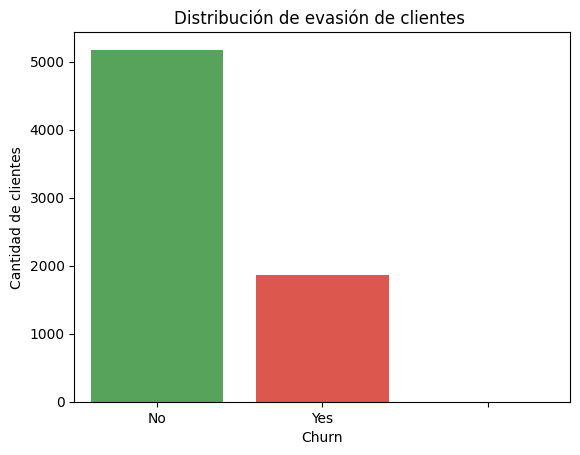

In [24]:

sns.countplot(x='Churn', data=df, hue='Churn',
              palette={'No':'#4CAF50', 'Yes':'#F44336'},
              legend=False)

plt.title('Distribución de evasión de clientes ')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')

plt.show()

##Recuento de evasión por variables categóricas

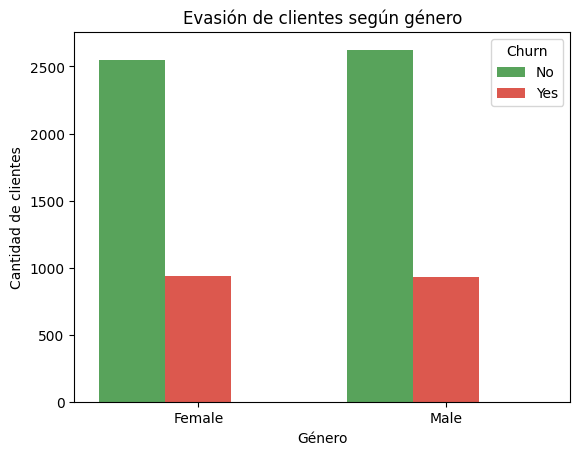

In [25]:
# churn vs género
sns.countplot(x='gender', hue='Churn', data=df,
              palette={'No':'#4CAF50','Yes':'#F44336'})

plt.title('Evasión de clientes según género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

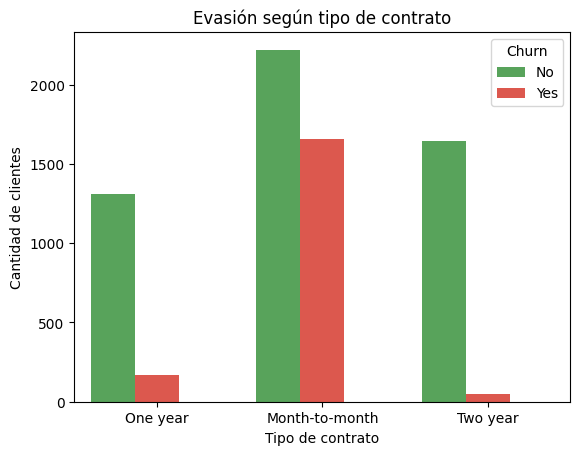

In [26]:
#churn vs tipo de contrato
sns.countplot(x='Contract', hue='Churn', data=df,
              palette={'No':'#4CAF50','Yes':'#F44336'})

plt.title('Evasión según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')

plt.show()

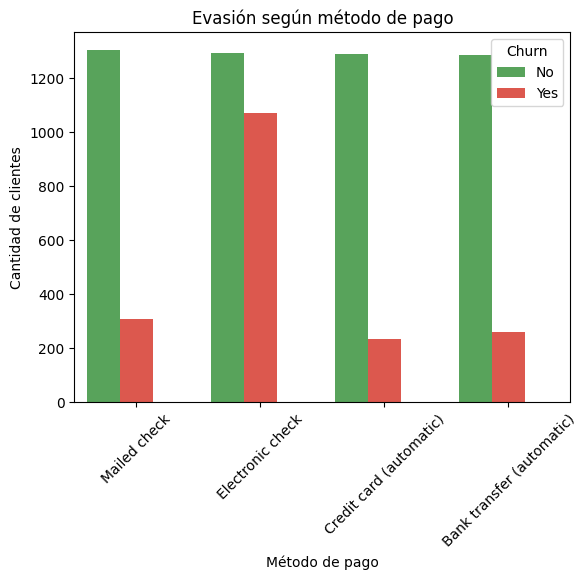

In [27]:
#churn vs método de pago
sns.countplot(x='PaymentMethod', hue='Churn', data=df,
              palette={'No':'#4CAF50','Yes':'#F44336'})

plt.title('Evasión según método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de clientes')

plt.xticks(rotation=45)

plt.show()

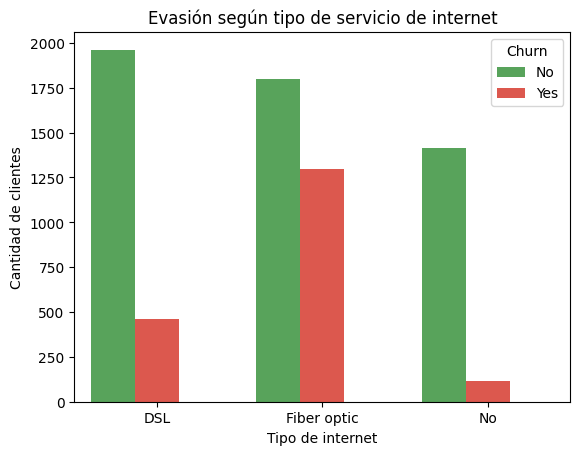

In [28]:
#Churn vs servicio de internet
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette={'No':'#4CAF50','Yes':'#F44336'})

plt.title('Evasión según tipo de servicio de internet')
plt.xlabel('Tipo de internet')
plt.ylabel('Cantidad de clientes')

plt.show()

##Conteo de evasión por variables numéricas

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns



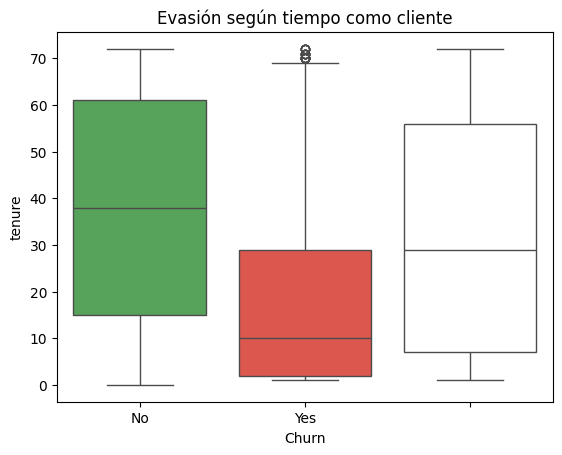

In [30]:
#churn vs tiempo como cliente
sns.boxplot(x='Churn', y='tenure', data=df,
            hue='Churn',
            palette={'No':'#4CAF50','Yes':'#F44336'},
            legend=False)

plt.title('Evasión según tiempo como cliente')
plt.show()

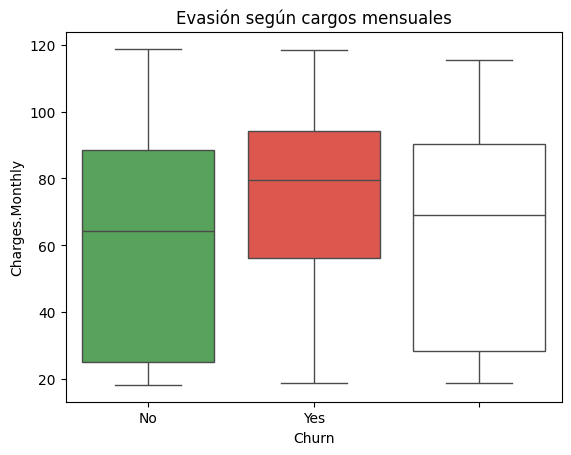

In [31]:
#Churn vs cargos mensuales
sns.boxplot(x='Churn', y='Charges.Monthly', data=df,
            hue='Churn',
            palette={'No':'#4CAF50','Yes':'#F44336'},
            legend=False)

plt.title('Evasión según cargos mensuales')
plt.show()

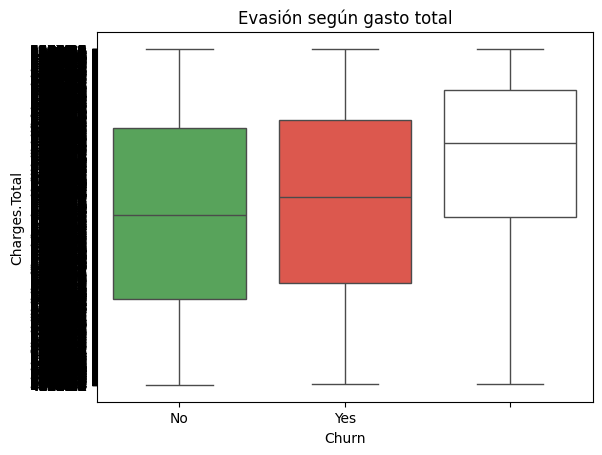

In [32]:
#Churn vs cargos totales
sns.boxplot(x='Churn', y='Charges.Total', data=df,
            hue='Churn',
            palette={'No':'#4CAF50','Yes':'#F44336'},
            legend=False)

plt.title('Evasión según gasto total')
plt.show()

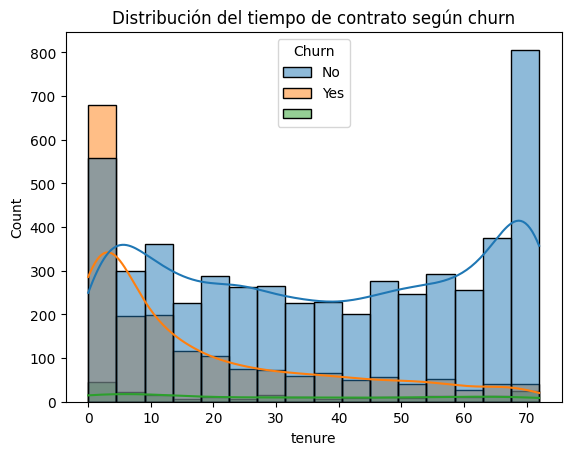

In [33]:
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)

plt.title('Distribución del tiempo de contrato según churn')

plt.show()

##**Conclusión e Insihgts**


A partir del análisis realizado se identificaron varios factores relacionados con la evasión de clientes:

- Los clientes con **contratos mensuales presentan mayor tasa de cancelación**.
- Los clientes con **menos tiempo en la empresa tienen mayor probabilidad de cancelar el servicio**.
- Los **cargos mensuales más altos** pueden estar asociados con una mayor evasión.

Estos hallazgos permiten identificar segmentos de clientes con mayor riesgo de abandono.

##**Recomendaciones**

Con base en los resultados obtenidos, se sugieren las siguientes estrategias:

- Promover contratos de mayor duración con incentivos.
- Implementar estrategias de retención para clientes nuevos.
- Revisar la estructura de precios para mejorar la percepción de valor.
- Utilizar modelos predictivos para identificar clientes con alto riesgo de evasión.